# **Maestría en Inteligencia Artificial Aplicada**
## Curso: **Análisis de grandes volúmenes de datos**
### Tecnológico de Monterrey
### Dr. Iván Olmos Pineda
###	Perla A. García Aguirre

# **Actividad 3 – Aprendizaje Supervisado y No Supervisado**

#### **Nombre y matrícula:**

*   Gustavo Alejandro Vázquez Rivas — [A01611559]

## 1. Introducción

**Aprendizaje supervisado.** Se entrena un modelo con datos que ya traen la respuesta correcta (una etiqueta `y`). El objetivo es aprender la relación entre las variables de entrada `X` y esa etiqueta para predecirla en datos nuevos. Cae en problemas de *clasificación* (etiqueta categórica) y *regresión* (etiqueta numérica).

**Aprendizaje no supervisado.** No hay etiqueta. El modelo busca estructura propia de los datos: grupos (clustering), reducción de dimensionalidad o reglas de asociación. Sirve para explorar y describir, no para predecir un valor conocido.

**Diferencia clave.** El supervisado optimiza contra una verdad conocida y se evalúa con métricas de error frente a esa etiqueta (accuracy, F1, RMSE). El no supervisado se mide con criterios internos de cohesión/separación (p. ej. *silhouette*), porque no existe una respuesta de referencia.

**Algoritmos supervisados en PySpark (`pyspark.ml.classification` / `.regression`).** `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier`, `GBTClassifier`, `NaiveBayes`, `LinearSVC`, `LinearRegression`, `GeneralizedLinearRegression`.

**Algoritmos no supervisados en PySpark (`pyspark.ml.clustering`).** `KMeans`, `BisectingKMeans`, `GaussianMixture`, `LDA`. Para reducción de dimensión existe `PCA` en `pyspark.ml.feature`.

**Por qué RandomForest y KMeans.** Para la parte supervisada elegimos `RandomForestClassifier` porque el problema es de clasificación binaria con variables mixtas (numéricas derivadas del texto + la fuente categórica): un ensamble de árboles maneja esa mezcla sin necesidad de escalar, captura interacciones no lineales (p. ej. una oración corta pero muy negativa) y, al promediar muchos árboles, reduce la varianza y resiste el sobreajuste mejor que un árbol único; además expone `featureImportances`, lo que facilita interpretar el modelo. Para la parte no supervisada usamos `KMeans` por ser el algoritmo de clustering particional más directo e interpretable de Spark: opera sobre las features numéricas estandarizadas, escala bien y permite leer cada grupo a través de su centroide y evaluar su calidad con *silhouette*. Es el punto de partida natural antes de métodos más costosos como `GaussianMixture`.

### Configuración del entorno
Spark necesita una JVM. Fijamos `JAVA_HOME` (si no está definido se intenta la ruta de Homebrew/openjdk@17) e inicializamos una `SparkSession` local. Reducimos las particiones de *shuffle* y el nivel de log para que el cuaderno sea ágil y legible.

In [1]:
import os

# Spark corre sobre la JVM: aseguramos JAVA_HOME antes de crear la sesión.
if not os.environ.get('JAVA_HOME'):
    for ruta in ['/opt/homebrew/opt/openjdk@17', '/usr/local/opt/openjdk@17',
                 '/usr/lib/jvm/java-17-openjdk']:
        if os.path.isdir(ruta):
            os.environ['JAVA_HOME'] = ruta
            break

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# Sesión local; 'local[*]' usa todos los núcleos disponibles.
spark = (SparkSession.builder
         .appName('Actividad3-PySparkML')
         .master('local[*]')
         .config('spark.sql.shuffle.partitions', '8')
         .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')  # menos ruido en la salida
print('Spark', spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/01 15:49:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.0.2


## 2. Selección de los datos

**Por qué Amazon, IMDB y Yelp.** Usamos los tres archivos del proyecto: `amazon_cells_labelled.txt`, `imdb_labelled.txt` y `yelp_labelled.txt` (*Sentiment Labelled Sentences*, UCI; Kotzias et al., KDD 2015). Cada uno recoge reseñas cortas de un dominio distinto —productos (Amazon), películas y series (IMDB) y restaurantes (Yelp)— con el sentimiento ya etiquetado, lo que los hace idóneos para los ejercicios de clasificación y clustering que pide la actividad.

**Comparten el mismo esquema.** Los tres tienen exactamente el mismo formato: una oración seguida de un `score` binario (`1` positivo / `0` negativo) separados por tabulador, con 500 positivas y 500 negativas cada uno (3000 registros en total). Al coincidir en estructura y en la escala de la etiqueta, es técnicamente correcto unirlos en una sola tabla.

**Por qué unirlos: reducir el sesgo de fuente única.** Entrenar con un solo dominio sesgaría el modelo hacia su vocabulario y estilo (por ejemplo, términos de electrónica en Amazon), y las métricas no generalizarían a otros contextos. Al combinar las tres plataformas obtenemos un conjunto más diverso y reducimos ese sesgo, conservando la procedencia en la variable categórica `source` por si aporta señal.

**Variables tras la lectura.** `sentence` (texto), `label` (entero 0/1, variable objetivo) y `source` (categórica: amazon/imdb/yelp).

In [2]:
# Detectamos automaticamente los archivos *_labelled.txt del directorio actual.
import glob
archivos = sorted(glob.glob('*_labelled.txt'))
print('Datasets encontrados:', archivos)

# Cada archivo se lee como texto plano y se etiqueta con su fuente.
dfs = []
for ruta in archivos:
    fuente = ruta.split('_')[0]           # 'amazon', 'imdb', 'yelp'
    tmp = (spark.read.text(ruta)
           .withColumn('source', F.lit(fuente)))
    dfs.append(tmp)

# Unimos las tres fuentes en un solo DataFrame.
raw = dfs[0]
for extra in dfs[1:]:
    raw = raw.unionByName(extra)

# El score es el ultimo 0/1 de la linea; la oracion es el resto sin ese score.
raw = (raw
       .withColumn('label', F.regexp_extract(F.trim('value'), r'([01])\s*$', 1).cast('int'))
       .withColumn('sentence', F.trim(F.regexp_replace(F.trim('value'), r'\t?[01]\s*$', '')))
       .select('sentence', 'label', 'source'))

print('Registros totales tras la union:', raw.count())
print('Columnas:', len(raw.columns), '->', raw.columns)
raw.groupBy('source').count().show()

Datasets encontrados: ['amazon_cells_labelled.txt', 'imdb_labelled.txt', 'yelp_labelled.txt']
Registros totales tras la union: 3000
Columnas: 3 -> ['sentence', 'label', 'source']
+------+-----+
|source|count|
+------+-----+
|amazon| 1000|
|  imdb| 1000|
|  yelp| 1000|
+------+-----+



### Construcción de la muestra M
Construimos la muestra `M` con `sample(fraction=0.60, seed=42)`. Fijar `seed=42` es lo que garantiza la **reproducibilidad**: cualquiera que ejecute el cuaderno obtiene exactamente la misma muestra y, por lo tanto, las mismas métricas. El muestreo es uniforme, así que conserva la proporción de clases (0/1) y de fuentes del conjunto original, sin perder la estructura del problema. Lo verificamos enseguida con el *shape*, el *schema* y los primeros registros.

In [3]:
# Muestra reproducible (~60% de los datos).
SEED = 42
M = raw.sample(withReplacement=False, fraction=0.60, seed=SEED).cache()

print('Shape de la muestra M: (%d filas, %d columnas)' % (M.count(), len(M.columns)))
print('\nSchema:')
M.printSchema()
print('Primeros registros:')
M.show(5, truncate=70)

Shape de la muestra M: (1818 filas, 3 columnas)

Schema:
root
 |-- sentence: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- source: string (nullable = false)

Primeros registros:
+----------------------------------------------------------------------+-----+------+
|                                                              sentence|label|source|
+----------------------------------------------------------------------+-----+------+
|                                           Good case, Excellent value.|    1|amazon|
|Tied to charger for conversations lasting more than 45 minutes.MAJO...|    0|amazon|
|I have to jiggle the plug to get it to line up right to get decent ...|    0|amazon|
|                           If you are Razr owner...you must have this!|    1|amazon|
|                                       And the sound quality is great.|    1|amazon|
+----------------------------------------------------------------------+-----+------+
only showing top 5 rows


## 3. Preparación de los datos

El texto crudo no es directamente consumible por los modelos tabulares de Spark ML. En lugar de embeddings, hacemos **ingeniería de variables**: a partir de cada oración derivamos métricas numéricas (longitud, conteo de palabras, signos, palabras en mayúscula) y dos conteos léxicos sencillos (palabras positivas/negativas). Junto con la fuente categórica forman un dataset tabular limpio. Es un enfoque PySpark nativo, interpretable y suficiente para los dos modelos que se piden.

### 3.1 Valores nulos

In [4]:
# Una linea malformada (sin score 0/1 al final) deja 'label' nulo.
# Tambien marcamos oraciones vacias como invalidas.
nulos = M.select([
    F.sum(F.col('label').isNull().cast('int')).alias('label_nulos'),
    F.sum((F.length('sentence') == 0).cast('int')).alias('sentence_vacias'),
    F.sum(F.col('source').isNull().cast('int')).alias('source_nulos'),
])
nulos.show()

+-----------+---------------+------------+
|label_nulos|sentence_vacias|source_nulos|
+-----------+---------------+------------+
|          0|              0|           0|
+-----------+---------------+------------+



**Decisión y justificación.** El conteo anterior no detectó valores faltantes, pero dejamos el control explícito por robustez del pipeline. La política es **eliminar** (no imputar) las filas con `label` nulo o `sentence` vacía, por dos razones: (i) `label` es la variable objetivo, e imputarla equivaldría a inventar la respuesta que el modelo debe aprender, introduciendo un sesgo directo; (ii) una oración vacía no genera features con señal. Cuando el dato faltante es la etiqueta —y no un predictor— descartar es preferible a imputar; además, al ser muy pocas (aquí ninguna), el impacto en el tamaño de la muestra es nulo.

In [5]:
antes = M.count()
M = M.filter(F.col('label').isNotNull() & (F.length('sentence') > 0))
print('Filas eliminadas:', antes - M.count(), '| Filas restantes:', M.count())

Filas eliminadas: 0 | Filas restantes: 1818


### 3.2 Construcción de variables numéricas y conversión de tipos

In [6]:
# Lexicos minimos para conteos de polaridad (no es un modelo de NLP, solo conteo).
pos = ['good','great','excellent','love','loved','amazing','awesome','best','nice',
       'wonderful','perfect','happy','recommend','fantastic','delicious','friendly',
       'comfortable','easy','works','well','enjoyed','favorite','pretty','beautiful']
neg = ['bad','worst','terrible','horrible','awful','hate','hated','poor','waste',
       'disappointed','disappointing','broke','broken','useless','slow','problem',
       'problems','cheap','boring','rude','nasty','bland','mediocre','return']

# Patrones regex con limites de palabra.
pat_pos = r'\b(' + '|'.join(pos) + r')\b'
pat_neg = r'\b(' + '|'.join(neg) + r')\b'

# Derivamos las features numericas directamente en Spark.
M_feat = (M
    .withColumn('char_count', F.length('sentence').cast('double'))
    .withColumn('word_count', F.size(F.split(F.trim('sentence'), r'\s+')).cast('double'))
    .withColumn('exclaim_count', F.regexp_count(F.col('sentence'), F.lit(r'!')).cast('double'))
    .withColumn('question_count', F.regexp_count(F.col('sentence'), F.lit(r'\?')).cast('double'))
    .withColumn('upper_count', F.regexp_count(F.col('sentence'), F.lit(r'\b[A-Z]{2,}\b')).cast('double'))
    .withColumn('pos_count', F.regexp_count(F.lower('sentence'), F.lit(pat_pos)).cast('double'))
    .withColumn('neg_count', F.regexp_count(F.lower('sentence'), F.lit(pat_neg)).cast('double'))
)
# Longitud media de palabra (caracteres sin espacios / numero de palabras).
M_feat = M_feat.withColumn(
    'avg_word_len',
    (F.length(F.regexp_replace('sentence', r'\s+', '')) / F.col('word_count')).cast('double'))

# Verificamos el schema final: todas las features numericas en double.
M_feat.printSchema()

root
 |-- sentence: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- source: string (nullable = false)
 |-- char_count: double (nullable = true)
 |-- word_count: double (nullable = true)
 |-- exclaim_count: double (nullable = true)
 |-- question_count: double (nullable = true)
 |-- upper_count: double (nullable = true)
 |-- pos_count: double (nullable = true)
 |-- neg_count: double (nullable = true)
 |-- avg_word_len: double (nullable = true)



Las features quedaron en `double` y `label` en `int`, que es justo lo que esperan `VectorAssembler` y los estimadores de Spark ML. La conversión de tipos se hizo con `cast` durante la derivación.

In [7]:
# Lista de columnas numericas que usaremos como features.
num_cols = ['char_count', 'word_count', 'avg_word_len', 'exclaim_count',
            'question_count', 'upper_count', 'pos_count', 'neg_count']
M_feat.select(['sentence'] + num_cols).show(5, truncate=45)

+---------------------------------------------+----------+----------+------------------+-------------+--------------+-----------+---------+---------+
|                                     sentence|char_count|word_count|      avg_word_len|exclaim_count|question_count|upper_count|pos_count|neg_count|
+---------------------------------------------+----------+----------+------------------+-------------+--------------+-----------+---------+---------+
|                  Good case, Excellent value.|      27.0|       4.0|               6.0|          0.0|           0.0|        0.0|      2.0|      0.0|
|Tied to charger for conversations lasting ...|      79.0|      11.0|6.2727272727272725|          2.0|           0.0|        2.0|      0.0|      1.0|
|I have to jiggle the plug to get it to lin...|      74.0|      17.0| 3.411764705882353|          0.0|           0.0|        0.0|      0.0|      0.0|
|  If you are Razr owner...you must have this!|      43.0|       8.0|               4.5|          1.

### 3.3 Variable categórica: StringIndexer + OneHotEncoder
`source` es nominal (amazon/imdb/yelp) y los estimadores de Spark ML solo consumen números. `StringIndexer` la convierte en índices enteros, pero esos índices impondrían un orden inexistente (amazon < yelp < imdb) que un modelo podría malinterpretar como una relación cuantitativa. Por eso aplicamos además `OneHotEncoder`, que representa la plataforma como un vector binario y elimina esa jerarquía artificial entre categorías.

In [8]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

# 'source' es nominal (3 plataformas) -> indexamos y luego one-hot.
# Se usa OneHotEncoder porque no hay orden entre las plataformas.
idx = StringIndexer(inputCol='source', outputCol='source_idx', handleInvalid='keep')
ohe = OneHotEncoder(inputCols=['source_idx'], outputCols=['source_ohe'])

idx_model = idx.fit(M_feat)        # guardamos el modelo para recuperar las etiquetas
M_enc = idx_model.transform(M_feat)
M_enc = ohe.fit(M_enc).transform(M_enc)
M_enc.select('source', 'source_idx', 'source_ohe').distinct().show()

+------+----------+-------------+
|source|source_idx|   source_ohe|
+------+----------+-------------+
|amazon|       0.0|(3,[0],[1.0])|
|  imdb|       2.0|(3,[2],[1.0])|
|  yelp|       1.0|(3,[1],[1.0])|
+------+----------+-------------+



### 3.4 Valores atípicos (IQR)

In [9]:
# Deteccion basica de outliers por el criterio del rango intercuartil (IQR).
print('%-16s %8s %8s %10s' % ('feature', 'Q1', 'Q3', 'outliers'))
for c in num_cols:
    q1, q3 = M_enc.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = M_enc.filter((F.col(c) < low) | (F.col(c) > high)).count()
    print('%-16s %8.2f %8.2f %10d' % (c, q1, q3, n_out))

feature                Q1       Q3   outliers
char_count          32.00    85.00         59
word_count           6.00    16.00         40
avg_word_len         4.07     5.12         73
exclaim_count        0.00     0.00        229
question_count       0.00     0.00         14
upper_count          0.00     0.00        144
pos_count            0.00     1.00         15
neg_count            0.00     0.00        265


**Por qué IQR y qué encontramos.** Usamos el rango intercuartil (valores fuera de `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`) porque es una detección no paramétrica que no asume normalidad, adecuada para variables de conteo. El resultado muestra que los conteos (signos, palabras positivas/negativas) tienen colas largas: la mayoría de oraciones vale 0 y unas pocas varios, por lo que el IQR marca muchas como atípicas aunque sean valores legítimos. **No las eliminamos**, y lo justificamos así: son reseñas reales y enfáticas que aportan señal de polaridad, y `RandomForest` —al partir por umbrales y no por distancia— es robusto a ellas. Para `KMeans`, que sí es sensible a magnitudes, el riesgo se mitiga con la estandarización del paso siguiente, no recortando los datos.

### 3.5 Escalamiento y construcción de `features`
**`VectorAssembler`.** Los estimadores de Spark ML no reciben columnas sueltas, sino un único vector de predictores. `VectorAssembler` agrupa las variables numéricas y la fuente one-hot en la columna `features`, que es el formato que exigen tanto el clasificador como el modelo de clustering.

**`StandardScaler` solo para KMeans.** Para el **modelo supervisado** usamos `features` sin escalar, porque los árboles parten por umbrales y son invariantes a la escala de cada variable. Para **KMeans**, en cambio, sí aplicamos `StandardScaler` (media 0, desviación 1): al basarse en la distancia euclidiana, sin estandarizar una variable de rango amplio como `char_count` dominaría sobre conteos pequeños como `pos_count` y distorsionaría los grupos. Por eso el escalamiento se aplica únicamente en la rama de clustering y no en la supervisada.

In [10]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

# features para el modelo supervisado: numericas + fuente one-hot.
assembler = VectorAssembler(inputCols=num_cols + ['source_ohe'], outputCol='features')
data = assembler.transform(M_enc)

# Vector solo-numerico estandarizado para KMeans.
num_assembler = VectorAssembler(inputCols=num_cols, outputCol='num_vec')
data = num_assembler.transform(data)
scaler = StandardScaler(inputCol='num_vec', outputCol='num_scaled', withMean=True, withStd=True)
data = scaler.fit(data).transform(data).cache()

data.select('features', 'num_scaled', 'label').show(3, truncate=55)

+-------------------------------------------------------+-------------------------------------------------------+-----+
|                                               features|                                             num_scaled|label|
+-------------------------------------------------------+-------------------------------------------------------+-----+
|                (11,[0,1,2,6,8],[27.0,4.0,6.0,2.0,1.0])|[-0.8386606966723191,-0.9753484879716727,1.180964357...|    1|
|[79.0,11.0,6.2727272727272725,2.0,0.0,2.0,0.0,1.0,1....|[0.31509272485645695,-0.10388286570617318,1.43711983...|    0|
|       (11,[0,1,2,8],[74.0,17.0,3.411764705882353,1.0])|[0.20415489586330543,0.6430876676642551,-1.250001332...|    0|
+-------------------------------------------------------+-------------------------------------------------------+-----+
only showing top 3 rows


## 4. Preparación de entrenamiento y prueba

Dividimos la muestra en **80% entrenamiento / 20% prueba** con `randomSplit` y `seed=42`. La justificación de esta proporción es doble. Por un lado, el conjunto de prueba queda totalmente fuera del entrenamiento, lo que permite estimar el desempeño sobre datos no vistos y **detectar sobreajuste**: si el bosque memorizara el train, su error en test sería mucho peor, y al comparar ambos lo notaríamos. Por otro lado, el reparto 80/20 reduce el **sesgo de evaluación** para este tamaño (~1800 filas): el 80% aporta suficientes ejemplos para que el modelo aprenda patrones estables, y el 20% (~360 filas) es lo bastante grande para que las métricas no dependan de unos pocos casos. La semilla fija hace reproducible la partición. Verificamos además el balance de la clase objetivo `label`, porque solo con clases equilibradas la *accuracy* es directamente interpretable.

In [11]:
train, test = data.randomSplit([0.8, 0.2], seed=SEED)
train = train.cache(); test = test.cache()
print('Train:', train.count(), '| Test:', test.count())

# Balance de clases (la muestra esta practicamente balanceada 0/1).
print('\nBalance de clases en train:')
train.groupBy('label').count().orderBy('label').show()

Train: 1458 | Test: 360

Balance de clases en train:
+-----+-----+
|label|count|
+-----+-----+
|    0|  742|
|    1|  716|
+-----+-----+



## 5. Modelo de aprendizaje supervisado

**Variable objetivo.** La elección natural es `label` (sentimiento 0/1): es la única etiqueta provista, está balanceada (~50/50) y define un problema de clasificación binaria claro. `source` no sirve como objetivo porque es solo metadato de procedencia, no algo que queramos predecir.

**Por qué RandomForest es adecuado.** El problema combina features numéricas (derivadas del texto) con la fuente categórica, y `RandomForestClassifier` se ajusta bien a ese escenario: (i) integra ambos tipos de variable sin requerir escalamiento; (ii) captura relaciones no lineales e interacciones (por ejemplo, una oración corta pero con `neg_count` alto); (iii) al promediar muchos árboles entrenados sobre submuestras, reduce la varianza y resiste el sobreajuste mejor que un árbol individual; y (iv) expone `featureImportances`, que nos deja interpretar qué variables pesan. Es compatible con el dataset, por lo que no fue necesario recurrir a `DecisionTreeClassifier`.

In [12]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

rf = RandomForestClassifier(labelCol='label', featuresCol='features',
                            numTrees=100, maxDepth=8, seed=SEED)
rf_model = rf.fit(train)
pred = rf_model.transform(test)
pred.select('label', 'prediction', 'probability').show(5, truncate=40)

+-----+----------+----------------------------------------+
|label|prediction|                             probability|
+-----+----------+----------------------------------------+
|    1|       0.0|[0.6402377948337064,0.35976220516629365]|
|    0|       0.0|[0.8768695257865499,0.12313047421345011]|
|    1|       1.0|[0.08117830240082317,0.9188216975991768]|
|    0|       0.0| [0.6813072909112029,0.3186927090887971]|
|    0|       0.0|[0.6434823861175735,0.35651761388242664]|
+-----+----------+----------------------------------------+
only showing top 5 rows


In [13]:
# Calculamos las cuatro metricas reales sobre el conjunto de prueba.
def evaluar(pred, etiqueta='label', prediccion='prediction'):
    metricas = {}
    for nombre, m in [('accuracy', 'accuracy'), ('f1', 'f1'),
                      ('precision', 'weightedPrecision'),
                      ('recall', 'weightedRecall')]:
        ev = MulticlassClassificationEvaluator(labelCol=etiqueta,
                                                predictionCol=prediccion,
                                                metricName=m)
        metricas[nombre] = ev.evaluate(pred)
    return metricas

met = evaluar(pred)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    print('%-10s: %.4f' % (k.capitalize(), met[k]))

Accuracy  : 0.7500
Precision : 0.7650
Recall    : 0.7500
F1        : 0.7469


**Interpretación de las métricas.** Sobre el conjunto de prueba el modelo obtuvo Accuracy ≈ 0.75, Precision ≈ 0.765, Recall ≈ 0.75 y F1 ≈ 0.747. La *accuracy* indica que clasifica correctamente alrededor de 3 de cada 4 reseñas; al estar las clases balanceadas, este valor es comparable directamente contra el 0.50 del azar. La *precision* (0.765) es la proporción de aciertos entre las reseñas que el modelo predijo como positivas; el *recall* (0.75) es la proporción de positivas reales que logró recuperar; y el *F1* (0.747), su media armónica, confirma que el modelo no sacrifica una métrica a costa de la otra, es decir, mantiene un desempeño equilibrado entre ambas clases.

**Variables más importantes y su significado.** La importancia se concentra en `pos_count` (≈ 0.50) y `neg_count` (≈ 0.19): juntas explican cerca del 70% de las decisiones del bosque. Es coherente, porque son las únicas variables que codifican polaridad léxica directa —cuántas palabras claramente positivas o negativas contiene la oración—, justo la señal que define el sentimiento. Les siguen, con peso mucho menor, las variables de *forma* del texto (`avg_word_len`, `char_count`, `word_count`), mientras que la fuente (`source`) y `question_count` casi no influyen. Esto confirma que la capacidad predictiva proviene sobre todo de las **características léxicas derivadas del texto**, y no de su longitud ni de la plataforma de origen. El desempeño supera con claridad al azar pero queda por debajo de un enfoque con embeddings, algo esperable al usar únicamente features léxicas y estructurales simples.

pos_count        0.4977
neg_count        0.1881
avg_word_len     0.0846
char_count       0.0814
word_count       0.0680
exclaim_count    0.0226
upper_count      0.0177
source=imdb      0.0149
source=amazon    0.0123
source=yelp      0.0082
question_count   0.0045


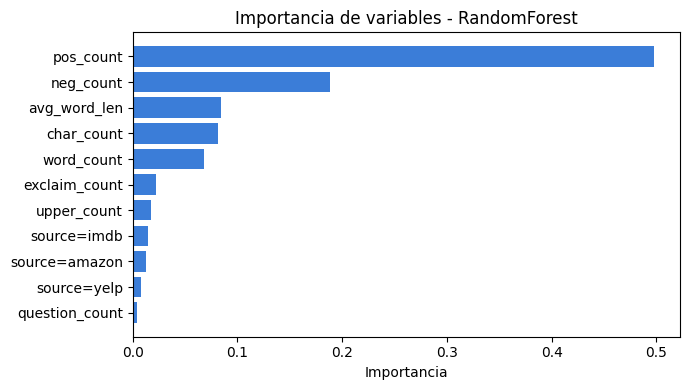

In [14]:
import matplotlib.pyplot as plt

# Importancia de variables. Mapeamos cada peso a su nombre de feature.
nombres = num_cols + ['source=%s' % s for s in idx_model.labels]
importancias = rf_model.featureImportances.toArray()
pares = sorted(zip(nombres[:len(importancias)], importancias),
               key=lambda x: x[1], reverse=True)
for nombre, imp in pares:
    print('%-16s %.4f' % (nombre, imp))

etqs = [p[0] for p in pares]
vals = [p[1] for p in pares]
plt.figure(figsize=(7, 4))
plt.barh(etqs[::-1], vals[::-1], color='#3b7dd8')
plt.title('Importancia de variables - RandomForest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## 6. Modelo de aprendizaje no supervisado

**Por qué KMeans.** Es el algoritmo de clustering particional más directo e interpretable de Spark ML: agrupa por cercanía a centroides en el espacio de features, escala bien a conjuntos grandes y permite leer cada grupo a través de su centroide. Como aquí queremos explorar si la *forma* de las reseñas genera grupos naturales, KMeans es un punto de partida razonable antes de recurrir a métodos más complejos como `GaussianMixture`.

**Variables para clustering.** Usamos las 8 features numéricas ya estandarizadas (`num_scaled`). Excluimos `label` a propósito: el clustering debe encontrar estructura sin ver la etiqueta, para después contrastar los grupos contra ella. También excluimos la fuente one-hot, de modo que los grupos se formen por características del texto y no por la plataforma de origen.

**Elección de k mediante silhouette.** No hay un `k` correcto a priori, así que probamos `k = 2..5` y elegimos el de mayor *silhouette*, métrica que mide la cohesión interna de cada grupo frente a su separación de los demás (valores más altos = grupos mejor definidos). El mejor resultado fue **k = 4** (silhouette ≈ 0.39), que usamos en el modelo final.

In [15]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(featuresCol='num_scaled', metricName='silhouette',
                                distanceMeasure='squaredEuclidean')

# Buscamos el k con mejor silhouette entre 2 y 5.
print('%3s %12s' % ('k', 'silhouette'))
resultados = {}
for k in range(2, 6):
    km = KMeans(featuresCol='num_scaled', k=k, seed=SEED)
    modelo_k = km.fit(data)
    sil = evaluator.evaluate(modelo_k.transform(data))
    resultados[k] = sil
    print('%3d %12.4f' % (k, sil))

mejor_k = max(resultados, key=resultados.get)
print('\nMejor k segun silhouette:', mejor_k)

  k   silhouette
  2       0.3486
  3       0.3733
  4       0.3878
  5       0.2801

Mejor k segun silhouette: 4


In [16]:
# Entrenamos KMeans con el mejor k y generamos los clusters.
kmeans = KMeans(featuresCol='num_scaled', k=mejor_k, seed=SEED)
km_model = kmeans.fit(data)
clusters = km_model.transform(data)

# Tamano de cada cluster.
print('Tamano de cada cluster:')
clusters.groupBy('prediction').count().orderBy('prediction').show()

# Silhouette del modelo final.
sil_final = evaluator.evaluate(clusters)
print('Silhouette (k=%d): %.4f' % (mejor_k, sil_final))

Tamano de cada cluster:
+----------+-----+
|prediction|count|
+----------+-----+
|         0| 1217|
|         1|   29|
|         2|    8|
|         3|  564|
+----------+-----+

Silhouette (k=4): 0.3878


In [17]:
# Centroides en el espacio estandarizado (una fila por cluster).
import numpy as np
centros = km_model.clusterCenters()
print('Centroides (features estandarizadas):')
print('%-8s' % 'cluster', ' '.join('%9s' % c[:9] for c in num_cols))
for i, c in enumerate(centros):
    print('%-8d' % i, ' '.join('%9.2f' % v for v in c))

Centroides (features estandarizadas):
cluster  char_coun word_coun avg_word_ exclaim_c question_ upper_cou pos_count neg_count
0            -0.51     -0.53      0.10     -0.04     -0.01     -0.15     -0.05     -0.04
1            -0.35     -0.39      0.26      0.92      0.23      5.90     -0.32      0.37
2            -0.46     -0.66      2.09     11.31     -0.08      0.87      0.13     -0.39
3             1.13      1.18     -0.26     -0.11      0.02      0.01      0.11      0.08


In [18]:
# Comparamos clusters vs sentimiento real para interpretarlos.
clusters.groupBy('prediction').pivot('label').count().orderBy('prediction').show()

+----------+---+---+
|prediction|  0|  1|
+----------+---+---+
|         0|609|608|
|         1| 20|  9|
|         2|  4|  4|
|         3|287|277|
+----------+---+---+



**Interpretación de los centroides.** Leyendo los centroides estandarizados, los cuatro grupos se distinguen por la *forma* del texto, no por su sentimiento: el cluster 0 (el más grande, 1217 reseñas) reúne textos cortos y típicos, con longitud por debajo del promedio; el cluster 3 (564) agrupa las reseñas largas, con `char_count` y `word_count` muy por encima de la media; el cluster 1 (29) destaca por un `upper_count` altísimo (texto en mayúsculas, estilo "gritado"); y el cluster 2 (8) es un grupo minúsculo con valores extremos de `exclaim_count` y `avg_word_len`.

**Cruce cluster–sentimiento.** Al cruzar los clusters con la etiqueta real, los dos grupos grandes quedan repartidos casi 50/50 entre positivas y negativas (609/608 y 287/277), lo que muestra que KMeans **no** separa la polaridad: agrupa por longitud e intensidad del texto. El único sesgo apreciable es el cluster 1 (mayúsculas), que se inclina a negativo (20 vs 9), coherente con reseñas de enojo escritas en altas; con tan pocos casos, sin embargo, conviene tomarlo con cautela.

**Qué aporta el clustering frente al supervisado.** Aunque no predice el sentimiento, el clustering revela información que el modelo supervisado no entrega: identifica *segmentos de estilo* (reseñas cortas, largas, en mayúsculas, hiper-enfáticas) que existen de forma transversal a la etiqueta. Es información descriptiva, útil por ejemplo para detectar reseñas atípicas o para moderación de contenido, y por tanto **complementa** al clasificador en lugar de sustituirlo: uno responde "¿qué sentimiento tiene?" y el otro "¿qué tipos de texto hay?".

## 7. Discusión de resultados

Los dos modelos respondieron preguntas distintas y conviene no compararlos como si midieran lo mismo. El supervisado, que sí usa la etiqueta, alcanzó un F1 de 0.747: un resultado decente si consideramos que solo le entregamos ocho variables construidas a mano. Su acierto descansa casi por completo en los conteos léxicos (`pos_count`, `neg_count`), lo cual era previsible, porque fueron precisamente las features que diseñamos para capturar la polaridad. El no supervisado, en cambio, con un silhouette de 0.39 formó grupos poco nítidos y organizados por la longitud y el énfasis del texto, no por su sentimiento.

Vale la pena conectar esto con las decisiones de preparación de datos. Que `pos_count` y `neg_count` dominen confirma que la calidad del clasificador quedó atada a la de esos léxicos, que armamos manualmente y son cortos; con un vocabulario distinto el resultado habría cambiado. La estandarización fue determinante para que KMeans no se dejara llevar por `char_count`: sin ella, los grupos habrían sido todavía más una simple partición por tamaño. Y la decisión de conservar los outliers en lugar de recortarlos explica que aparezcan clusters diminutos como el 1 y el 2, que son justo las reseñas extremas que el clustering aísla.

La limitación de fondo es el propio enfoque de variables manuales. Contar palabras de una lista fija ignora el contexto, no maneja negaciones como "no es bueno" ni el sarcasmo, y depende de que el vocabulario de la reseña coincida con nuestros léxicos. Un enfoque con embeddings —como el del cuaderno previo— captura significado y normalmente supera con holgura este techo; el costo es que pierde la interpretabilidad que aquí sí tenemos, donde podemos señalar exactamente qué variable empujó cada predicción.

Como mejoras futuras, lo más rentable sería sustituir los conteos por una representación de texto nativa de Spark (`Tokenizer` + `CountVectorizer`/`HashingTF` + `IDF`), ampliar y depurar los léxicos, ajustar los hiperparámetros del bosque con `CrossValidator`, y para el clustering probar `BisectingKMeans` o reducir dimensión con `PCA` antes de agrupar.

### Tabla comparativa: Random Forest vs. KMeans

| Aspecto | Random Forest | KMeans |
|---|---|---|
| **Objetivo** | Predecir el sentimiento (0/1) de cada reseña | Agrupar reseñas por similitud, sin etiqueta |
| **Tipo de aprendizaje** | Supervisado (clasificación binaria) | No supervisado (clustering) |
| **Variables usadas** | 8 features numéricas + `source` one-hot (`features`) | 8 features numéricas estandarizadas (`num_scaled`) |
| **Métricas utilizadas** | Accuracy, Precision, Recall, F1 | Silhouette + inspección de centroides y tamaños |
| **Resultado obtenido** | Accuracy 0.75 · Precision 0.765 · Recall 0.75 · F1 0.747 | k = 4 · Silhouette 0.39 · clusters de 1217/29/8/564 |
| **Ventajas observadas** | Métricas claras e interpretables; maneja variables mixtas sin escalar; `featureImportances` revela que `pos_count`/`neg_count` mandan; robusto a outliers | No necesita etiquetas; descubre *segmentos de estilo* (cortas, largas, en mayúsculas) que el clasificador no muestra; rápido e interpretable vía centroides |
| **Limitaciones encontradas** | Techo bajo por usar features léxicas manuales; ignora contexto, negaciones y sarcasmo; depende de léxicos cortos | Silhouette bajo (grupos difusos); no recupera la polaridad (clusters ~50/50 vs. etiqueta); sensible a la escala (requiere estandarización) y al `k` elegido |

## 8. Conclusiones
Lo que más me llamó la atención durante esta actividad fue que el desempeño de los modelos dependió mucho más de las variables construidas que del algoritmo utilizado. Aunque Random Forest obtuvo un F1 Score de 0.747 y logró identificar correctamente una buena parte del sentimiento de las reseñas, al analizar la importancia de las variables quedó claro que gran parte de ese resultado provino de los conteos de palabras positivas y negativas definidos durante la etapa de preparación de datos.

Por otro lado, el resultado obtenido con KMeans me permitió entender mejor la diferencia entre aprendizaje supervisado y no supervisado. Aunque los clusters no lograron separar claramente las reseñas positivas y negativas, sí identificaron patrones relacionados con la forma en que las personas escriben sus opiniones, como la longitud de los textos o el uso de ciertos elementos de escritura. Esto demuestra que ambos enfoques pueden aportar información valiosa, pero desde perspectivas distintas.

También pude comprobar que la preparación de los datos es una de las etapas más importantes de cualquier proyecto de aprendizaje automático. En este caso, trabajar con variables construidas manualmente permitió obtener resultados razonables, pero al mismo tiempo evidenció ciertas limitaciones para capturar el contexto completo de las reseñas. Probablemente el desempeño podría mejorar utilizando representaciones más avanzadas del texto, aunque eso implicaría aumentar la complejidad del proceso.

Finalmente, la integración de reseñas provenientes de Amazon, IMDB y Yelp permitió trabajar con una muestra más variada y menos dependiente de una sola fuente de información. Además, mantener una semilla fija durante el muestreo hizo posible reproducir los resultados obtenidos y comparar de manera consistente el comportamiento de ambos modelos. En conjunto, la actividad me permitió aplicar de forma práctica conceptos de aprendizaje supervisado y no supervisado utilizando PySpark, así como entender mejor el impacto que tienen las decisiones de preparación de datos sobre los resultados finales.


In [19]:
# Liberamos la sesion de Spark al finalizar.
spark.stop()

# **Fin de la Actividad 3 – PySpark ML**